# SMS Spam Detection NLP Project

This notebook mirrors the workflow of the original Twitter sentiment notebook, but uses the SMS Spam Collection dataset.

In [14]:

# Install once if needed
# !pip install datasets wordcloud nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, nltk

from datasets import load_dataset
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [15]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/uciml/sms-spam-collection-dataset/versions/1


In [16]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "spam.csv"), encoding="latin-1")

df = df[['v1', 'v2']]
df.columns = ['label_name', 'message']

df['label'] = df['label_name'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label_name,message,label
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## Shape

In [17]:
df.shape

(5572, 3)

## Info

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   label_name  5572 non-null   str  
 1   message     5572 non-null   str  
 2   label       5572 non-null   int64
dtypes: int64(1), str(2)
memory usage: 584.9 KB


## Missing Values

In [19]:
df.isnull().sum()

label_name    0
message       0
label         0
dtype: int64

## Duplicates

In [20]:
print(df.duplicated().sum())

403


## Remove Missing & Duplicates

In [21]:
df=df.dropna().drop_duplicates().reset_index(drop=True); df.head()

,label_name,message,label
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## Class Distribution

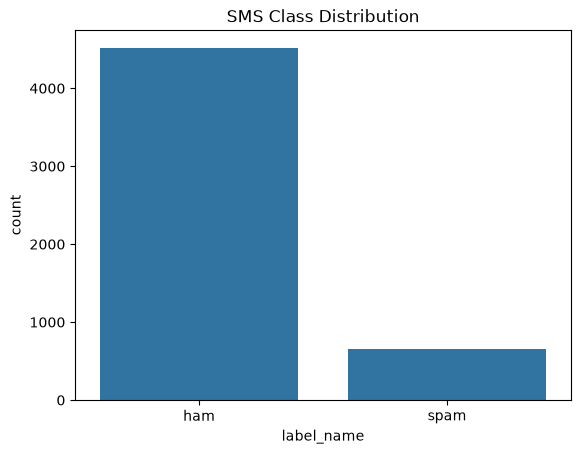

In [22]:

sns.countplot(data=df,x="label_name")
plt.title("SMS Class Distribution")
plt.show()


## Pie Chart

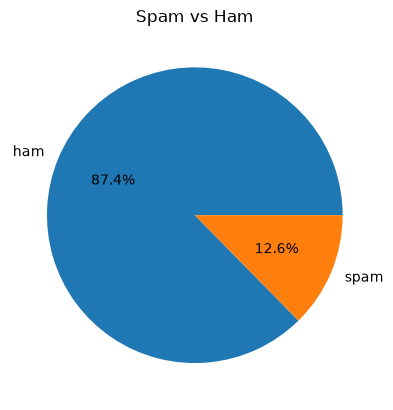

In [23]:

df["label_name"].value_counts().plot.pie(autopct="%1.1f%%")
plt.ylabel("")
plt.title("Spam vs Ham")
plt.show()


## Message Length

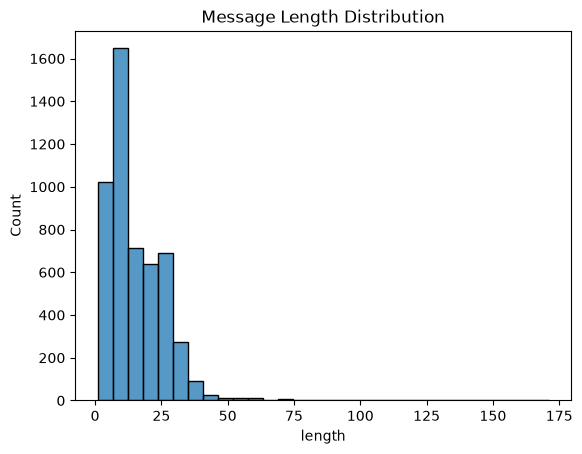

In [24]:

df["length"]=df["message"].str.split().str.len()
sns.histplot(df["length"],bins=30)
plt.title("Message Length Distribution")
plt.show()


## Text Preprocessing

In [25]:

stop=set(stopwords.words("english"))
lem=WordNetLemmatizer()

def clean(text):
    text=text.lower()
    text=re.sub(r"http\S+","",text)
    text=re.sub(r"[^a-z ]"," ",text)
    words=[lem.lemmatize(w) for w in text.split() if w not in stop]
    return " ".join(words)

df["clean_text"]=df["message"].apply(clean)
df[["message","clean_text"]].head()


,message,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though


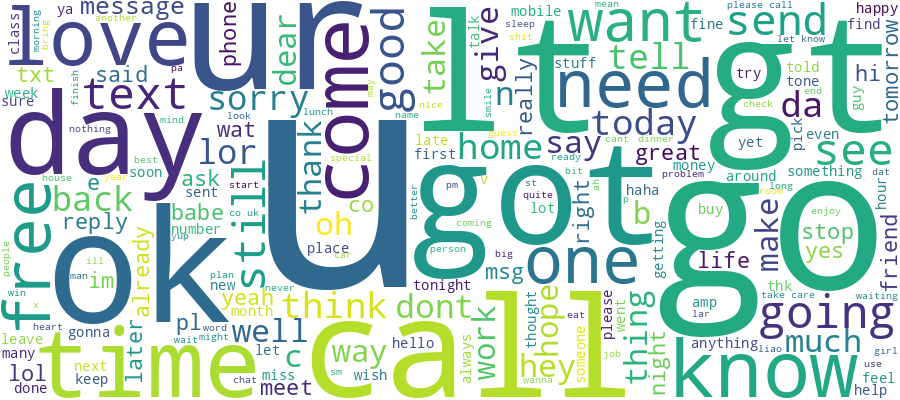

In [26]:

text=" ".join(df.clean_text)
WordCloud(width=900,height=400,background_color="white").generate(text).to_image()


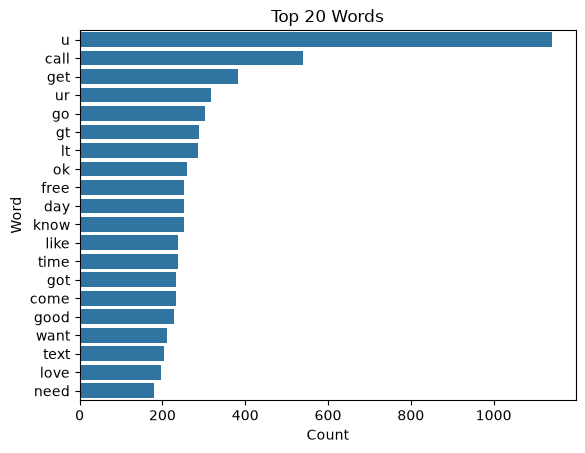

In [27]:

words=Counter(" ".join(df.clean_text).split()).most_common(20)
wdf=pd.DataFrame(words,columns=["Word","Count"])
sns.barplot(data=wdf,x="Count",y="Word")
plt.title("Top 20 Words")
plt.show()


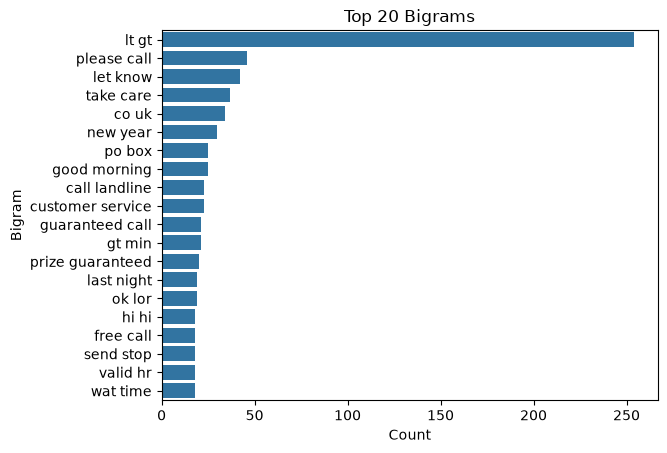

In [28]:

from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(ngram_range=(2,2),max_features=20)
X=cv.fit_transform(df.clean_text)
counts=np.asarray(X.sum(axis=0)).ravel()
bigrams=pd.DataFrame({"Bigram":cv.get_feature_names_out(),"Count":counts}).sort_values("Count",ascending=False)
sns.barplot(data=bigrams,x="Count",y="Bigram")
plt.title("Top 20 Bigrams")
plt.show()


## Model Training

In [29]:

X_train,X_test,y_train,y_test=train_test_split(df.clean_text,df.label,test_size=0.2,random_state=42,stratify=df.label)

tfidf=TfidfVectorizer(max_features=5000)
Xtr=tfidf.fit_transform(X_train)
Xte=tfidf.transform(X_test)

model=LogisticRegression(max_iter=1000)
model.fit(Xtr,y_train)

pred=model.predict(Xte)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred,target_names=["ham","spam"]))


Accuracy: 0.9622823984526112
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       1.00      0.70      0.83       131

    accuracy                           0.96      1034
   macro avg       0.98      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034



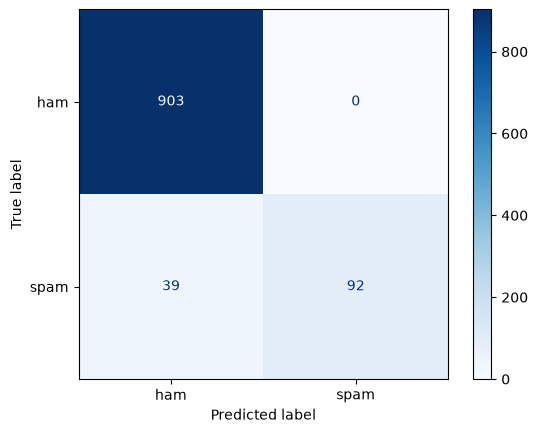

In [30]:

cm=confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm,display_labels=["ham","spam"]).plot(cmap="Blues")
plt.show()


## Top Spam Words

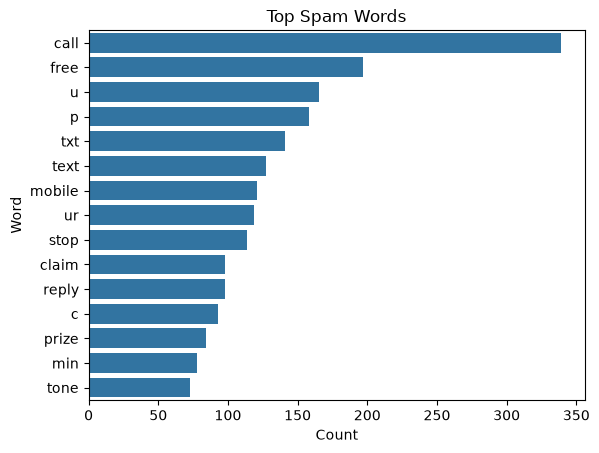

In [31]:

spam=" ".join(df[df.label==1].clean_text)
spam_words=Counter(spam.split()).most_common(15)
sdf=pd.DataFrame(spam_words,columns=["Word","Count"])
sns.barplot(data=sdf,x="Count",y="Word")
plt.title("Top Spam Words")
plt.show()


## Custom Prediction

In [32]:

def predict_sms(msg):
    c=clean(msg)
    p=model.predict(tfidf.transform([c]))[0]
    return "Spam" if p==1 else "Ham"

examples=[
"Congratulations! You won a free iPhone. Call now!",
"Can we meet at 6 pm today?"
]

for e in examples:
    print(e)
    print("Prediction:",predict_sms(e))
    print()


Congratulations! You won a free iPhone. Call now!
Prediction: Spam

Can we meet at 6 pm today?
Prediction: Ham

